# Smart Drone Command Language Analyzer Using Basic NLP

### Course: Natural Language Processing
### Course Code: CSE 306
### CA Project

This project implements a basic Natural Language Processing system that
accepts or rejects simple English drone command sentences.

The system performs:
- Tokenization
- Role identification
- Subject-Verb-Object parsing
- Corpus-based sentence validation
- Rejection reason generation
- Dynamic corpus addition
- Dataset display

## Problem Statement

Consider a simple language consisting of English sentences related to
delivery drones. Each sentence contains a subject noun, a verb and an
object noun.

The objective is to build a basic NLP program that accepts or rejects a
new sentence. If the sentence is accepted, the program identifies the
role of each word. If it is rejected, the program provides an appropriate
reason for rejection.

## Objective

The objectives of this project are:

1. To create a small corpus of 20 simple English sentences.
2. To tokenize input sentences.
3. To identify Subject, Verb and Object.
4. To perform simple sentence parsing.
5. To determine whether a sentence belongs to the defined language.
6. To provide a reason when a sentence is rejected.
7. To allow users to add new sentences to the corpus.
8. To display the current corpus dynamically.
9. To understand the basic phases of an NLP application.

## NLP Concepts Used

This project uses the following basic NLP concepts:

### 1. Corpus
A collection of sentences used to define our simple language.

### 2. Tokenization
Breaking a sentence into individual words.

### 3. Role Identification
Identifying whether a word acts as a Subject, Verb or Object.

### 4. Parsing
Understanding the basic grammatical structure of the sentence.

### 5. Sentence Validation
Checking whether the sentence follows the rules of our defined language.

In [1]:
import re
import pandas as pd

In [2]:
corpus = [
    "Drone delivers package",
    "Drone carries parcel",
    "Drone transports box",
    "Drone delivers medicine",
    "Drone carries food",
    "Drone transports goods",
    "Robot delivers package",
    "Robot carries parcel",
    "Robot transports box",
    "Robot delivers medicine",
    "Robot carries food",
    "Robot transports goods",
    "Drone drops package",
    "Drone moves parcel",
    "Drone picks package",
    "Robot drops package",
    "Robot moves parcel",
    "Robot picks package",
    "Drone delivers parcel",
    "Robot delivers goods"
]

print("Number of sentences in corpus:", len(corpus))

Number of sentences in corpus: 20


In [3]:
print("DRONE COMMAND CORPUS")
print("=" * 40)

for i, sentence in enumerate(corpus, start=1):
    print(f"{i}. {sentence}")

DRONE COMMAND CORPUS
1. Drone delivers package
2. Drone carries parcel
3. Drone transports box
4. Drone delivers medicine
5. Drone carries food
6. Drone transports goods
7. Robot delivers package
8. Robot carries parcel
9. Robot transports box
10. Robot delivers medicine
11. Robot carries food
12. Robot transports goods
13. Drone drops package
14. Drone moves parcel
15. Drone picks package
16. Robot drops package
17. Robot moves parcel
18. Robot picks package
19. Drone delivers parcel
20. Robot delivers goods


In [4]:
subjects = {
    "drone",
    "robot"
}

verbs = {
    "delivers",
    "carries",
    "transports",
    "drops",
    "moves",
    "picks"
}

objects = {
    "package",
    "parcel",
    "box",
    "medicine",
    "food",
    "goods"
}

print("Subjects:", subjects)
print("Verbs:", verbs)
print("Objects:", objects)

Subjects: {'robot', 'drone'}
Verbs: {'drops', 'picks', 'transports', 'carries', 'delivers', 'moves'}
Objects: {'parcel', 'box', 'medicine', 'goods', 'package', 'food'}


In [5]:
def tokenize(sentence):
    sentence = sentence.lower().strip()
    tokens = re.findall(r'\b\w+\b', sentence)
    return tokens


test_sentence = "Drone delivers package"

print("Sentence:", test_sentence)
print("Tokens:", tokenize(test_sentence))

Sentence: Drone delivers package
Tokens: ['drone', 'delivers', 'package']


In [6]:
def identify_roles(tokens):
    roles = []

    for word in tokens:
        if word in subjects:
            roles.append((word, "Subject"))
        elif word in verbs:
            roles.append((word, "Verb"))
        elif word in objects:
            roles.append((word, "Object"))
        else:
            roles.append((word, "Unknown"))

    return roles


tokens = tokenize("Drone delivers package")

print(identify_roles(tokens))

[('drone', 'Subject'), ('delivers', 'Verb'), ('package', 'Object')]


In [7]:
def parse_sentence(tokens):
    if len(tokens) != 3:
        return None

    subject, verb, obj = tokens

    if subject in subjects and verb in verbs and obj in objects:
        return {
            "Subject": subject,
            "Verb": verb,
            "Object": obj
        }

    return None

In [8]:
tokens = tokenize("Drone delivers package")

parsed = parse_sentence(tokens)

print(parsed)

{'Subject': 'drone', 'Verb': 'delivers', 'Object': 'package'}


In [9]:
def validate_sentence(sentence):
    tokens = tokenize(sentence)

    # Rule 1: Empty sentence
    if len(tokens) == 0:
        return False, "The sentence is empty."

    # Rule 2: Exactly three words required
    if len(tokens) != 3:
        return False, "Sentence must contain exactly 3 words: Subject + Verb + Object."

    subject, verb, obj = tokens

    # Rule 3: Subject check
    if subject not in subjects:
        return False, f"'{subject}' is not a valid subject in the corpus."

    # Rule 4: Verb check
    if verb not in verbs:
        return False, f"'{verb}' is not a valid verb in the corpus."

    # Rule 5: Object check
    if obj not in objects:
        return False, f"'{obj}' is not a valid object in the corpus."

    # Rule 6: Check exact sentence corpus
    normalized_sentence = " ".join(tokens)

    normalized_corpus = [
        " ".join(tokenize(s))
        for s in corpus
    ]

    if normalized_sentence not in normalized_corpus:
        return False, "Sentence structure is valid, but the sentence is not in my corpus."

    return True, "Sentence accepted."

In [10]:
def analyze_sentence(sentence):
    print("\n" + "=" * 50)
    print("INPUT SENTENCE:", sentence)
    print("=" * 50)

    tokens = tokenize(sentence)

    print("Tokens:", tokens)

    accepted, reason = validate_sentence(sentence)

    if accepted:
        print("\nSTATUS: ACCEPTED")
        print("Reason:", reason)

        roles = identify_roles(tokens)

        print("\nWord Roles:")
        for word, role in roles:
            print(f"{word:15} -> {role}")

        parsed = parse_sentence(tokens)

        print("\nSimple Parse:")
        print(parsed)

    else:
        print("\nSTATUS: REJECTED")
        print("Reason:", reason)

In [11]:
analyze_sentence("Drone delivers package")


INPUT SENTENCE: Drone delivers package
Tokens: ['drone', 'delivers', 'package']

STATUS: ACCEPTED
Reason: Sentence accepted.

Word Roles:
drone           -> Subject
delivers        -> Verb
package         -> Object

Simple Parse:
{'Subject': 'drone', 'Verb': 'delivers', 'Object': 'package'}


In [12]:
analyze_sentence("Car delivers package")


INPUT SENTENCE: Car delivers package
Tokens: ['car', 'delivers', 'package']

STATUS: REJECTED
Reason: 'car' is not a valid subject in the corpus.


In [13]:
analyze_sentence("Drone flies package")


INPUT SENTENCE: Drone flies package
Tokens: ['drone', 'flies', 'package']

STATUS: REJECTED
Reason: 'flies' is not a valid verb in the corpus.


In [14]:
analyze_sentence("Drone delivers car")


INPUT SENTENCE: Drone delivers car
Tokens: ['drone', 'delivers', 'car']

STATUS: REJECTED
Reason: 'car' is not a valid object in the corpus.


In [15]:
analyze_sentence("Car delivers package")


INPUT SENTENCE: Car delivers package
Tokens: ['car', 'delivers', 'package']

STATUS: REJECTED
Reason: 'car' is not a valid subject in the corpus.


In [16]:
analyze_sentence("Drone carries medicine")


INPUT SENTENCE: Drone carries medicine
Tokens: ['drone', 'carries', 'medicine']

STATUS: REJECTED
Reason: Sentence structure is valid, but the sentence is not in my corpus.


In [17]:
analyze_sentence("Drone carries medicine")


INPUT SENTENCE: Drone carries medicine
Tokens: ['drone', 'carries', 'medicine']

STATUS: REJECTED
Reason: Sentence structure is valid, but the sentence is not in my corpus.


In [18]:
def add_sentence(sentence):
    normalized = " ".join(tokenize(sentence))

    existing = [
        " ".join(tokenize(s))
        for s in corpus
    ]

    if normalized in existing:
        print("Sentence already exists in the corpus.")
        return

    tokens = tokenize(sentence)

    if len(tokens) != 3:
        print("Cannot add sentence.")
        print("Sentence must have Subject + Verb + Object.")
        return

    subject, verb, obj = tokens

    if subject not in subjects:
        print("Cannot add sentence.")
        print(f"Unknown subject: {subject}")
        return

    if verb not in verbs:
        print("Cannot add sentence.")
        print(f"Unknown verb: {verb}")
        return

    if obj not in objects:
        print("Cannot add sentence.")
        print(f"Unknown object: {obj}")
        return

    corpus.append(sentence)

    print("Sentence successfully added!")

In [19]:
add_sentence("Drone carries medicine")

Sentence successfully added!


In [20]:
print("Updated corpus size:", len(corpus))

Updated corpus size: 21


In [21]:
analyze_sentence("Drone carries medicine")


INPUT SENTENCE: Drone carries medicine
Tokens: ['drone', 'carries', 'medicine']

STATUS: ACCEPTED
Reason: Sentence accepted.

Word Roles:
drone           -> Subject
carries         -> Verb
medicine        -> Object

Simple Parse:
{'Subject': 'drone', 'Verb': 'carries', 'Object': 'medicine'}


In [22]:
def display_corpus():
    print("\nCURRENT DRONE COMMAND CORPUS")
    print("=" * 50)

    for i, sentence in enumerate(corpus, start=1):
        print(f"{i}. {sentence}")

In [23]:
display_corpus()


CURRENT DRONE COMMAND CORPUS
1. Drone delivers package
2. Drone carries parcel
3. Drone transports box
4. Drone delivers medicine
5. Drone carries food
6. Drone transports goods
7. Robot delivers package
8. Robot carries parcel
9. Robot transports box
10. Robot delivers medicine
11. Robot carries food
12. Robot transports goods
13. Drone drops package
14. Drone moves parcel
15. Drone picks package
16. Robot drops package
17. Robot moves parcel
18. Robot picks package
19. Drone delivers parcel
20. Robot delivers goods
21. Drone carries medicine


In [24]:
def display_corpus():
    print("\nCURRENT DRONE COMMAND CORPUS")
    print("=" * 50)

    for i, sentence in enumerate(corpus, start=1):
        print(f"{i}. {sentence}")

In [25]:
display_corpus()


CURRENT DRONE COMMAND CORPUS
1. Drone delivers package
2. Drone carries parcel
3. Drone transports box
4. Drone delivers medicine
5. Drone carries food
6. Drone transports goods
7. Robot delivers package
8. Robot carries parcel
9. Robot transports box
10. Robot delivers medicine
11. Robot carries food
12. Robot transports goods
13. Drone drops package
14. Drone moves parcel
15. Drone picks package
16. Robot drops package
17. Robot moves parcel
18. Robot picks package
19. Drone delivers parcel
20. Robot delivers goods
21. Drone carries medicine


In [26]:
def show_vocabulary():
    print("\nDRONE COMMAND VOCABULARY")
    print("=" * 50)
    
    print("Subjects:")
    for word in sorted(subjects):
        print(" -", word)
    
    print("\nVerbs:")
    for word in sorted(verbs):
        print(" -", word)
    
    print("\nObjects:")
    for word in sorted(objects):
        print(" -", word)

In [27]:
show_vocabulary()


DRONE COMMAND VOCABULARY
Subjects:
 - drone
 - robot

Verbs:
 - carries
 - delivers
 - drops
 - moves
 - picks
 - transports

Objects:
 - box
 - food
 - goods
 - medicine
 - package
 - parcel


In [28]:
def menu():
    while True:
        print("\n")
        print("=" * 50)
        print("DRONE COMMAND NLP ANALYZER")
        print("=" * 50)
        print("1. Analyze a sentence")
        print("2. Add a new sentence")
        print("3. Display corpus")
        print("4. Display vocabulary")
        print("5. Exit")

        choice = input("\nEnter your choice (1-5): ")

        if choice == "1":
            sentence = input("Enter a sentence: ")
            analyze_sentence(sentence)

        elif choice == "2":
            sentence = input("Enter sentence to add: ")
            add_sentence(sentence)

        elif choice == "3":
            display_corpus()

        elif choice == "4":
            show_vocabulary()

        elif choice == "5":
            print("\nThank you for using the Drone Command NLP Analyzer!")
            break

        else:
            print("\nInvalid choice. Please enter a number from 1 to 5.")

In [35]:
menu()



DRONE COMMAND NLP ANALYZER
1. Analyze a sentence
2. Add a new sentence
3. Display corpus
4. Display vocabulary
5. Exit

INPUT SENTENCE: Drone delivers package
Tokens: ['drone', 'delivers', 'package']

STATUS: ACCEPTED
Reason: Sentence accepted.

Word Roles:
drone           -> Subject
delivers        -> Verb
package         -> Object

Simple Parse:
{'Subject': 'drone', 'Verb': 'delivers', 'Object': 'package'}


DRONE COMMAND NLP ANALYZER
1. Analyze a sentence
2. Add a new sentence
3. Display corpus
4. Display vocabulary
5. Exit

Thank you for using the Drone Command NLP Analyzer!


In [36]:
menu()



DRONE COMMAND NLP ANALYZER
1. Analyze a sentence
2. Add a new sentence
3. Display corpus
4. Display vocabulary
5. Exit
Sentence successfully added!


DRONE COMMAND NLP ANALYZER
1. Analyze a sentence
2. Add a new sentence
3. Display corpus
4. Display vocabulary
5. Exit

Thank you for using the Drone Command NLP Analyzer!


In [37]:
menu()



DRONE COMMAND NLP ANALYZER
1. Analyze a sentence
2. Add a new sentence
3. Display corpus
4. Display vocabulary
5. Exit

CURRENT DRONE COMMAND CORPUS
1. Drone delivers package
2. Drone carries parcel
3. Drone transports box
4. Drone delivers medicine
5. Drone carries food
6. Drone transports goods
7. Robot delivers package
8. Robot carries parcel
9. Robot transports box
10. Robot delivers medicine
11. Robot carries food
12. Robot transports goods
13. Drone drops package
14. Drone moves parcel
15. Drone picks package
16. Robot drops package
17. Robot moves parcel
18. Robot picks package
19. Drone delivers parcel
20. Robot delivers goods
21. Drone carries medicine
22. Robot carries medicine


DRONE COMMAND NLP ANALYZER
1. Analyze a sentence
2. Add a new sentence
3. Display corpus
4. Display vocabulary
5. Exit

Thank you for using the Drone Command NLP Analyzer!


In [38]:
menu()



DRONE COMMAND NLP ANALYZER
1. Analyze a sentence
2. Add a new sentence
3. Display corpus
4. Display vocabulary
5. Exit

DRONE COMMAND VOCABULARY
Subjects:
 - drone
 - robot

Verbs:
 - carries
 - delivers
 - drops
 - moves
 - picks
 - transports

Objects:
 - box
 - food
 - goods
 - medicine
 - package
 - parcel


DRONE COMMAND NLP ANALYZER
1. Analyze a sentence
2. Add a new sentence
3. Display corpus
4. Display vocabulary
5. Exit

Thank you for using the Drone Command NLP Analyzer!


## Test Cases and Results

The following test cases were used to evaluate the Drone Command NLP Analyzer.
The tests include valid sentences, invalid subjects, invalid verbs,
invalid objects, incorrect sentence length, and a sentence that is not
initially present in the corpus.

In [33]:
test_cases = [
    ("Drone delivers package", "Accepted"),
    ("Car delivers package", "Rejected"),
    ("Drone flies package", "Rejected"),
    ("Drone delivers car", "Rejected"),
    ("Drone delivers package quickly", "Rejected"),
    ("Drone carries medicine", "Accepted")
]

results_df = pd.DataFrame(
    test_cases,
    columns=["Test Sentence", "Expected Result"]
)

results_df

,Test Sentence,Expected Result
0,Drone delivers package,Accepted
1,Car delivers package,Rejected
2,Drone flies package,Rejected
3,Drone delivers car,Rejected
4,Drone delivers package quickly,Rejected
5,Drone carries medicine,Accepted


### Result Analysis

The test results show that the system can distinguish between accepted
and rejected sentences.

A sentence is accepted when:
- It contains exactly three words.
- The subject belongs to the defined subject vocabulary.
- The verb belongs to the defined verb vocabulary.
- The object belongs to the defined object vocabulary.
- The complete sentence exists in the corpus.

A sentence is rejected when one or more of these conditions are not
satisfied.

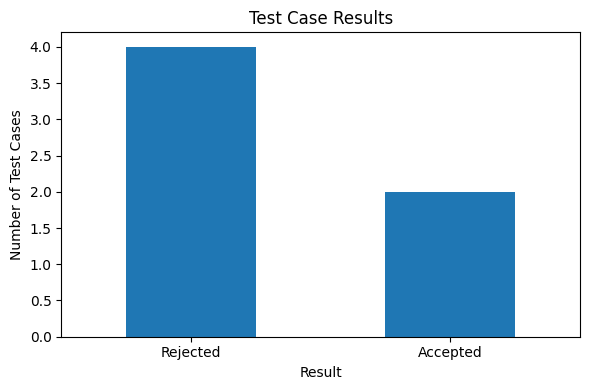

In [34]:
import matplotlib.pyplot as plt

result_counts = results_df["Expected Result"].value_counts()

plt.figure(figsize=(6, 4))
result_counts.plot(kind="bar")
plt.title("Test Case Results")
plt.xlabel("Result")
plt.ylabel("Number of Test Cases")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Dataset Description

The dataset used in this project is a small custom corpus of drone command
sentences. Each command follows a simple Subject + Verb + Object structure.

The corpus contains commands involving two subjects: drone and robot.
The verbs include carries, delivers, drops, moves, picks, and transports.
The objects include box, food, goods, medicine, package, and parcel.

The initial corpus contains 20 predefined sentences. The system also allows
the user to add new valid sentences dynamically to the corpus.

The dataset is designed specifically for demonstrating basic NLP concepts
such as tokenization, vocabulary identification, sentence validation,
word-role identification, and simple parsing.

## Key Findings

1. The system successfully tokenizes input sentences into individual words.
2. Subject, verb, and object roles are identified using predefined vocabularies.
3. Valid three-word commands can be accepted and parsed.
4. Invalid subjects, verbs, and objects are detected and rejected.
5. Sentences with an incorrect number of words are rejected.
6. The system checks whether the complete sentence exists in the corpus.
7. New valid commands can be added dynamically to the corpus.
8. The interactive menu provides a simple way to use all major functions.

## Limitations

1. The system supports only a small predefined vocabulary.
2. Commands must follow exactly the Subject + Verb + Object structure.
3. The system does not understand complex or natural-language variations.
4. The sentence must exist in the corpus to be accepted.
5. The project uses basic rule-based NLP rather than advanced NLP models.
6. The system does not handle synonyms or different grammatical structures.

## Conclusion

The Drone Command NLP Analyzer demonstrates how basic NLP techniques can
be used to process and validate simple drone commands. The system performs
tokenization, vocabulary checking, sentence validation, word-role
identification, and simple parsing. It also supports dynamic addition of
new commands and provides an interactive menu for users.

The project successfully demonstrates the practical use of basic NLP
concepts for a simple command-analysis application.